## generate toy data

/var/folders/j3/fhsxl53s3yg5k1x235r8_w6m0000gn/T/ipykernel_66169/2955724956.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


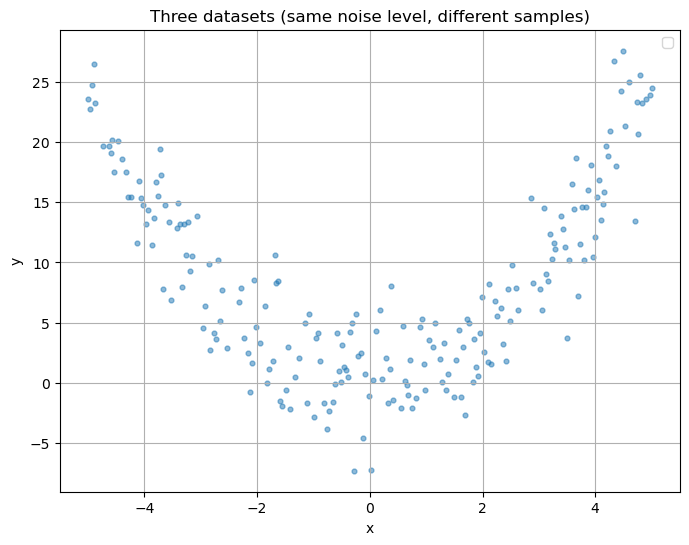

In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Reproducibility (global seed)
base_rng = np.random.default_rng(42)

# Settings
n_points = 300
x = np.linspace(-5, 5, n_points)
noise_std = 3.0      # SAME noise level for all datasets
n_datasets = 3

all_datasets = []

for i in range(1, n_datasets + 1):
    # Use different RNG stream → different datasets but same distribution
    rng = np.random.default_rng(42 + i)

    # Generate noisy data
    y_clean = x**2
    noise = rng.normal(0, noise_std, size=x.shape)
    y = y_clean + noise

    df = pd.DataFrame({"x": x, "y": y})

    # Split (70 / 15 / 15)
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

    # Save
    df.to_csv(f"dataset_{i}_full.csv", index=False)
    train_df.to_csv(f"dataset_{i}_train.csv", index=False)
    val_df.to_csv(f"dataset_{i}_val.csv", index=False)
    test_df.to_csv(f"dataset_{i}_test.csv", index=False)

    all_datasets.append(df)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(train_df["x"], train_df["y"], s=12, alpha=0.5)

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Three datasets (same noise level, different samples)")
plt.grid(True)
plt.show()

## building the model

In [6]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

print(torch.__version__)

class MLPsym(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_size2, output_size):
        super(MLPsym, self).__init__()
        self.input = nn.Linear(input_size, hidden_size)
        self.hidden = nn.Linear(hidden_size, hidden_size2)
        self.output = nn.Linear(hidden_size2, output_size)
        self.activation = nn.LeakyReLU()

    
    def forward(self, x):
        '''
        Args
            x (torch.Tensor): Shape (batch_size, 8000)
        '''
        out = self.input(x**2) # (batch_size, hidden_size)
        out = self.activation(out) 
        out = self.hidden(out) # (batch_size, hidden_size2)
        out = self.activation(out)
        out = self.output(out) # (batch_size, 1) \neq (batch_size)
        return out

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_size2, output_size):
        super(MLP, self).__init__()
        self.input = nn.Linear(input_size, hidden_size)
        self.hidden = nn.Linear(hidden_size, hidden_size2)
        self.output = nn.Linear(hidden_size2, output_size)
        self.activation = nn.LeakyReLU()

    
    def forward(self, x):
        '''
        Args
            x (torch.Tensor): Shape (batch_size, 8000)
        '''
        out = self.input(x) # (batch_size, hidden_size)
        out = self.activation(out) 
        out = self.hidden(out) # (batch_size, hidden_size2)
        out = self.activation(out)
        out = self.output(out) # (batch_size, 1) \neq (batch_size)
        return out

2.10.0


In [7]:
np.shape(train_df[["x"]].to_numpy())
#np.shaptrain_df["x"] = train_df["x"].abs()e(train_df[["y"]].to_numpy())
#train_df["x"] = train_df["x"].abs()

(210, 1)

In [8]:
train_features_tensor = torch.from_numpy(train_df[["x"]].to_numpy()).float()
valid_features_tensor = torch.from_numpy(val_df[["x"]].to_numpy()).float()
train_lables_tensor = torch.from_numpy(train_df[["y"]].to_numpy()).float()
valid_lables_tensor = torch.from_numpy(val_df[["y"]].to_numpy()).float()
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_features_tensor, train_lables_tensor)
val_dataset   = TensorDataset(valid_features_tensor, valid_lables_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [9]:
model1 = MLP(input_size=1, hidden_size=128*2, hidden_size2=128*2, output_size=1)
model1(train_features_tensor).shape

model2 = MLPsym(input_size=1, hidden_size=128*2, hidden_size2=128*2, output_size=1)
model2(train_features_tensor).shape

torch.Size([210, 1])

## training for no symmetry

In [11]:
def run_optimization(num_epochs: int, optimizer, criterion):
    model1.train() # Enable dropout, batch norm training mode, etc.
    loss_history = []
    for epoch in range(num_epochs):
        total_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()   # Zero gradients from previous step
            
            output = model1(data) # Forward pass
            loss = criterion(output, target) # Compute loss ((batch_size, 1) \times (batch_size))
            
            loss.backward()         # Backpropagation
            optimizer.step()        # Update weights
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss) # <--- 2. Store the average loss
        #print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    return loss_history # <--- 3. Return the list

# Optimizer
optimizer = optim.Adam(model1.parameters(), lr=1e-4)
# Loss Funciton
criterion = nn.MSELoss()
losses1=run_optimization(num_epochs=100, optimizer=optimizer, criterion=criterion)

## training fit

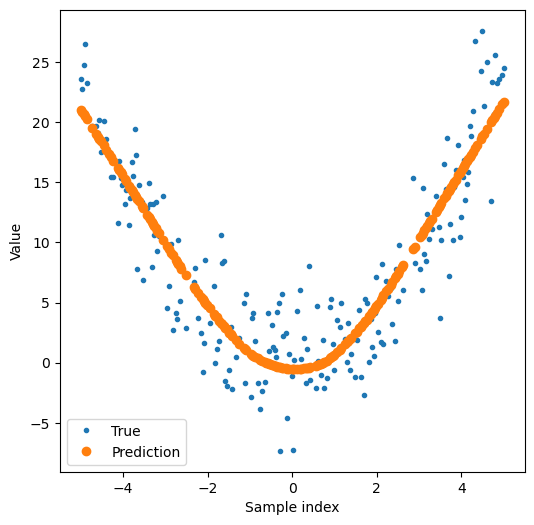

In [13]:
model1.eval()

with torch.no_grad():   # IMPORTANT
    x, y = train_dataset.tensors   # unpack tensors
    y_pred_test = model1(x).squeeze()

# If output is (N,1), flatten for plotting
y_pred_test = y_pred_test.squeeze()

plt.figure(figsize=(6,6))

plt.plot(x,y, 'o', markersize=3, label='True')
plt.plot(x,y_pred_test, 'o', label='Prediction')
plt.legend()
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.show()

### training with symmetry

In [15]:
def run_optimization2(num_epochs: int, optimizer, criterion):
    model2.train() # Enable dropout, batch norm training mode, etc.
    loss_history = []
    for epoch in range(num_epochs):
        total_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()   # Zero gradients from previous step
            
            output = model2(data) # Forward pass
            loss = criterion(output, target) # Compute loss ((batch_size, 1) \times (batch_size))
            
            loss.backward()         # Backpropagation
            optimizer.step()        # Update weights
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss) # <--- 2. Store the average loss
        #print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    return loss_history # <--- 3. Return the list

# Optimizer
optimizer = optim.Adam(model2.parameters(), lr=1e-4)
# Loss Funciton
criterion = nn.MSELoss()
losses2=run_optimization2(num_epochs=100, optimizer=optimizer, criterion=criterion)

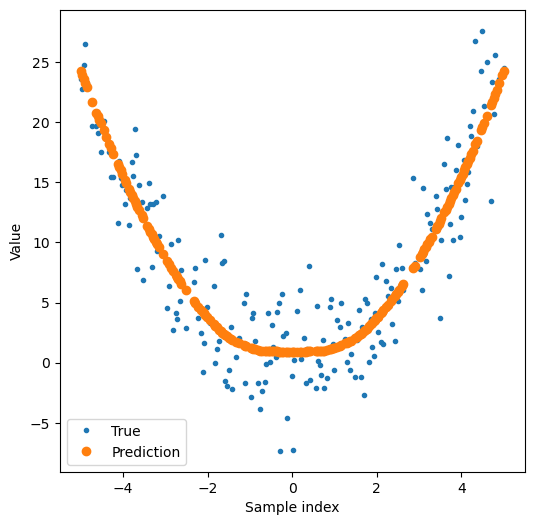

In [16]:
model2.eval()

with torch.no_grad():   # IMPORTANT
    x, y = train_dataset.tensors   # unpack tensors
    y_pred_test = model2(x).squeeze()

# If output is (N,1), flatten for plotting
y_pred_test = y_pred_test.squeeze()

plt.figure(figsize=(6,6))

plt.plot(x,y, 'o', markersize=3, label='True')
plt.plot(x,y_pred_test, 'o', label='Prediction')

plt.legend()
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.show()

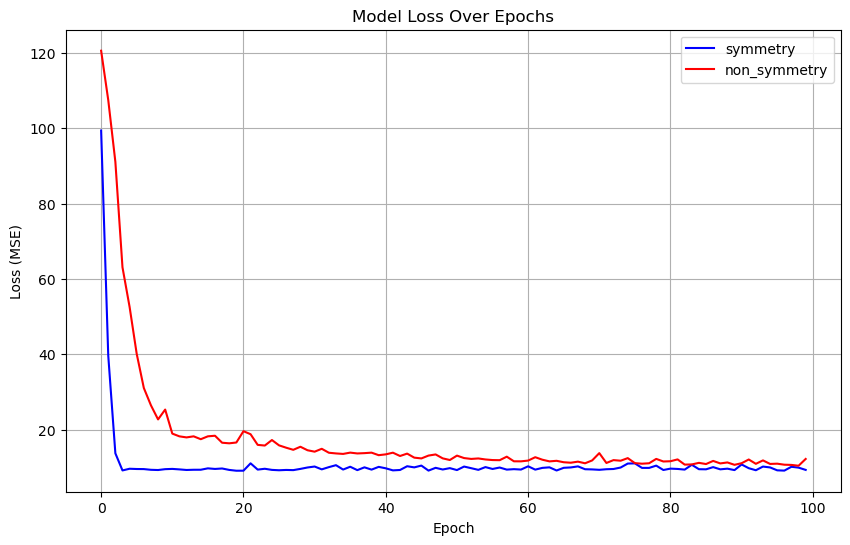

In [17]:
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(losses2, label='symmetry', color='blue')
plt.plot(losses1, label='non_symmetry', color='red')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()